In [1]:
import pickle
from torch.utils.data import Subset
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from utils.data import load_data,train_test_split
from utils.models import GINGraphClf,train_one_epoch,evaluate,test_evaluation


from utils.graph_function import baseline_explanation,subgraph_explanation
from utils.visualization import visualize_explanation

c:\Users\mahboub\miniforge3\envs\GNN\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\mahboub\miniforge3\envs\GNN\Lib\site-packages\torch_scatter\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\mahboub\miniforge3\envs\GNN\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\mahboub\miniforge3\envs\GNN\Lib\site-packages\torch_cluster\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\mahboub\miniforge3\envs\GNN\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\mahboub\miniforge3\envs\GNN\Lib\site-packages\torch_spline_conv\_version_cpu.pyd
  import torch_geometric.typing
c:

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

## loading data and split

In [3]:
dataset=load_data()
train_test_split(dataset)
with open("./data/splits.pkl", "rb") as f:
    splits=pickle.load(f)

train_dataset=Subset(dataset,splits["train"])
val_dataset=Subset(dataset,splits["val"])
test_dataset=Subset(dataset,splits["test"])


800 100 100
train,test,validation indices saved in ./data/splits.pkl


In [4]:

config={
    'hidden_dim':64,
    'learning_rate':0.001,
    'weight_decay':0.001,
    'epochs':100,
    'batch_size':32,
    'patience':10           # early stopping
}



In [5]:
train_loader=DataLoader(train_dataset,batch_size=config['batch_size'],shuffle=True)
validation_loader=DataLoader(val_dataset,batch_size=config['batch_size'],shuffle=False)
test_loader=DataLoader(test_dataset,batch_size=config['batch_size'],shuffle=False)

In [6]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


## Training

In [7]:
model=GINGraphClf(dataset.num_node_features,dataset.num_classes).to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=config['learning_rate'],weight_decay=config['weight_decay'])
criterion=nn.CrossEntropyLoss()

In [8]:
best_val_acc=0.0
patience_counter=0
best_model_state=None

train_losses = []
val_accs = []


with tqdm(total=config["epochs"],desc="Training epochs",unit="epoch") as pbar_epoch:
    for epoch in range(config["epochs"]):
        train_loss=train_one_epoch(model,train_loader,optimizer,criterion,device)
        val_acc=evaluate(model,validation_loader,device)
        train_losses.append(train_loss)
        val_accs.append(val_acc)
        pbar_epoch.set_postfix({"train_loss":train_loss,"val_acc":val_acc})
        pbar_epoch.update(1)
        if val_acc>best_val_acc:
            best_val_acc=val_acc
            patience_counter=0
            best_model_state=model.state_dict().copy()
        else:
            patience_counter+=1
            if patience_counter>=config["patience"]:
                tqdm.write(f"Early stopping at epoch {epoch+1}")
                break

model.load_state_dict(best_model_state)
tqdm.write(f"Best validation accuracy: {best_val_acc:.4f}")

Training epochs:  13%|█▎        | 13/100 [00:03<00:21,  4.07epoch/s, train_loss=0.315, val_acc=1]   

Early stopping at epoch 13
Best validation accuracy: 1.0000


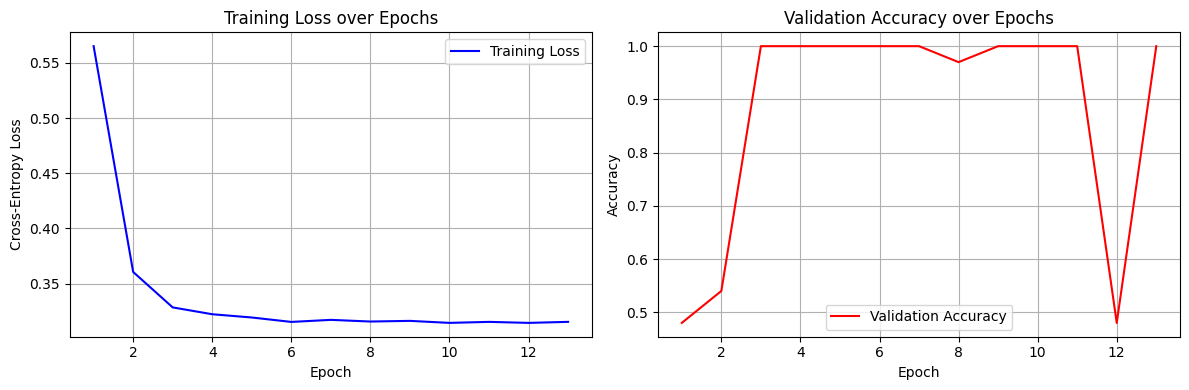

In [9]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, 'b-', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_accs, 'r-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy over Epochs')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Evaluating

In [10]:
model.eval()
for param in model.parameters():
    param.requires_grad = False


In [11]:
test_acc ,correct_indices,wrong_indices= test_evaluation(model, test_loader, device)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Number of correct predictions: {len(correct_indices)}")

Test Accuracy: 1.0000
Number of correct predictions: 100


In [12]:
test_result_split={
    "correct": correct_indices,
    "wrong": wrong_indices
}

# Explanation

In [13]:
ground_truth_motifs=[20,21,22,23,24]

In [14]:
def evaluate_explainer(
    model,
    test_dataset,
    test_result_split,
    ground_truth_motifs,
    explanation_fn,
    save_dir,
    device,
    budget=0.2,
    max_pic=10,
):
    total_precision = 0
    total_recall = 0
    fidelity_score_sum = 0

    gt_set = set(ground_truth_motifs)

    for key, samples in test_result_split.items():
        if len(samples) == 0:
            continue

        num_visualizations = min(max_pic, len(samples))
        random_indices = torch.randperm(len(samples))[:num_visualizations].tolist()

        for i, sample in enumerate(samples):

            data = test_dataset[sample["index"]]
            pred_class = sample["pred"]

            _, nodes, fidelity_score = explanation_fn(
                model,
                data,
                target_class=pred_class,
                budget=budget,
                device=device,
            )

            selected_nodes=nodes
            selected_set = set(selected_nodes)
            intersection = len(selected_set & gt_set)

            precision = (
                intersection / len(selected_set)
                if len(selected_set) > 0
                else 0
            )

            recall = (
                intersection / len(gt_set)
                if len(gt_set) > 0
                else 0
            )

            total_precision += precision
            total_recall += recall
            fidelity_score_sum += fidelity_score

            if i in random_indices:
                visualize_explanation(
                    data.cpu(),
                    selected_nodes,
                    save_path=f"{save_dir}/{key}/index_{sample['index']}.png",
                )

    precision = total_precision / len(test_dataset)
    recall = total_recall / len(test_dataset)
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    print(f"Fidelity score : {fidelity_score_sum / len(test_dataset):.4f}")
    print(f"Precision score: {precision:.4f}")
    print(f"Recall score   : {recall:.4f}")
    print(f"F1 score       : {f1:.4f}")

    return {
        "fidelity": fidelity_score_sum / len(test_dataset),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

### Subgraph Explanation

In [15]:
subgraph_results = evaluate_explainer(
    model=model,
    test_dataset=test_dataset,
    test_result_split=test_result_split,
    ground_truth_motifs=ground_truth_motifs,
    explanation_fn=subgraph_explanation,
    save_dir="./explanation/subgraph_explanation",
    device=device,
)

Fidelity score : 0.1189
Precision score: 0.9100
Recall score   : 0.9100
F1 score       : 0.9100


### Baseline

In [16]:
baseline_results = evaluate_explainer(
    model=model,
    test_dataset=test_dataset,
    test_result_split=test_result_split,
    ground_truth_motifs=ground_truth_motifs,
    explanation_fn=baseline_explanation,
    save_dir="./explanation/baseline",
    device=device,
)

Fidelity score : 0.4127
Precision score: 0.9630
Recall score   : 0.9420
F1 score       : 0.9524
